In [1]:
from google.colab import files
uploaded = files.upload()

Saving Customer_Segmentation_Dataset.xlsx to Customer_Segmentation_Dataset.xlsx


In [2]:
import pandas as pd

df = pd.read_excel("Customer_Segmentation_Dataset.xlsx")

In [3]:
df.head()

,CustomerID,Age,Gender,City,Annual Income,Spending Score,Purchase Frequency,Online Purchases
0,C001,58,Male,Visakhapatnam,34592,4,24,8
1,C002,26,Male,Bengaluru,116530,14,22,17
2,C003,45,Male,Bengaluru,24165,4,3,6
3,C004,56,Female,Visakhapatnam,23478,72,7,20
4,C005,46,Male,Chennai,97236,36,26,0


In [4]:
df.shape


(200, 8)

In [5]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'City', 'Annual Income',
       'Spending Score', 'Purchase Frequency', 'Online Purchases'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    object
 1   Age                 200 non-null    int64 
 2   Gender              200 non-null    object
 3   City                200 non-null    object
 4   Annual Income       200 non-null    int64 
 5   Spending Score      200 non-null    int64 
 6   Purchase Frequency  200 non-null    int64 
 7   Online Purchases    200 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 12.6+ KB


In [7]:
df.describe()

,Age,Annual Income,Spending Score,Purchase Frequency,Online Purchases
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,39.965000,86266.020000,49.675000,16.650000,10.515000
std,14.120578,37249.168915,29.150612,8.373054,5.804155
min,18.000000,20282.000000,1.000000,1.000000,0.000000
25%,26.750000,54918.250000,25.000000,10.000000,6.000000
50%,41.000000,89668.500000,48.500000,17.500000,10.500000
75%,51.000000,116349.250000,74.250000,23.250000,15.000000
max,65.000000,148232.000000,100.000000,30.000000,20.000000


In [8]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
City,0
Annual Income,0
Spending Score,0
Purchase Frequency,0
Online Purchases,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.sample(5)

,CustomerID,Age,Gender,City,Annual Income,Spending Score,Purchase Frequency,Online Purchases
39,C040,30,Male,Vijayawada,90292,58,5,13
23,C024,28,Male,Bengaluru,79470,1,24,8
70,C071,35,Female,Hyderabad,66025,83,17,12
53,C054,31,Male,Visakhapatnam,86307,34,5,11
88,C089,33,Female,Bengaluru,140254,16,15,4


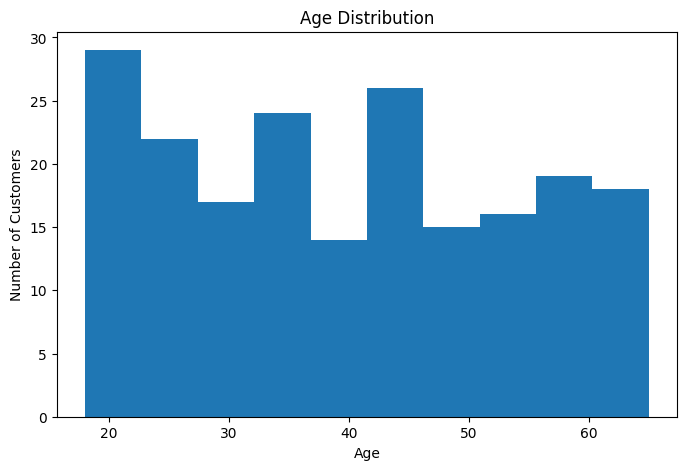

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

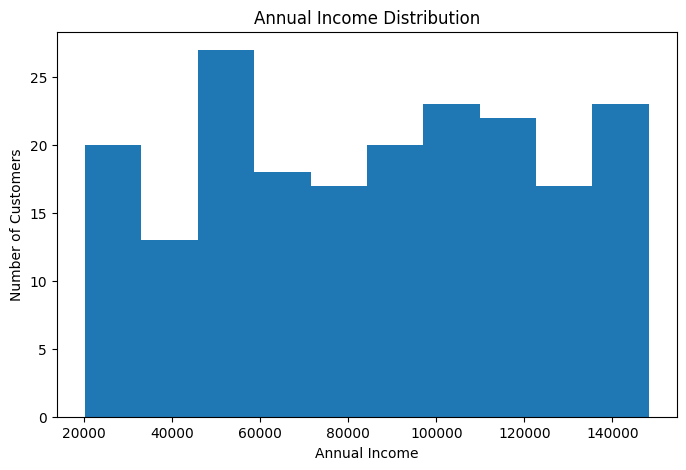

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df['Annual Income'], bins=10)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.show()


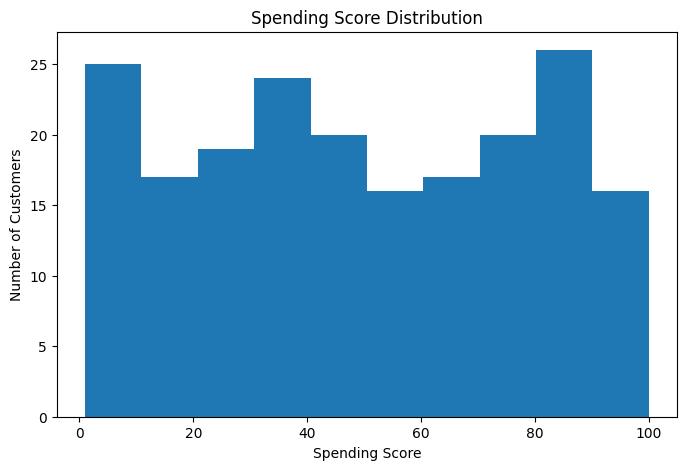

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Spending Score'], bins=10)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
correlation = df[['Age',
                  'Annual Income',
                  'Spending Score',
                  'Purchase Frequency',
                  'Online Purchases']].corr()

correlation

,Age,Annual Income,Spending Score,Purchase Frequency,Online Purchases
Age,1.000000,0.047874,-0.014287,0.138920,0.070670
Annual Income,0.047874,1.000000,0.002470,0.000375,0.024674
Spending Score,-0.014287,0.002470,1.000000,-0.048727,-0.022350
Purchase Frequency,0.138920,0.000375,-0.048727,1.000000,-0.099983
Online Purchases,0.070670,0.024674,-0.022350,-0.099983,1.000000


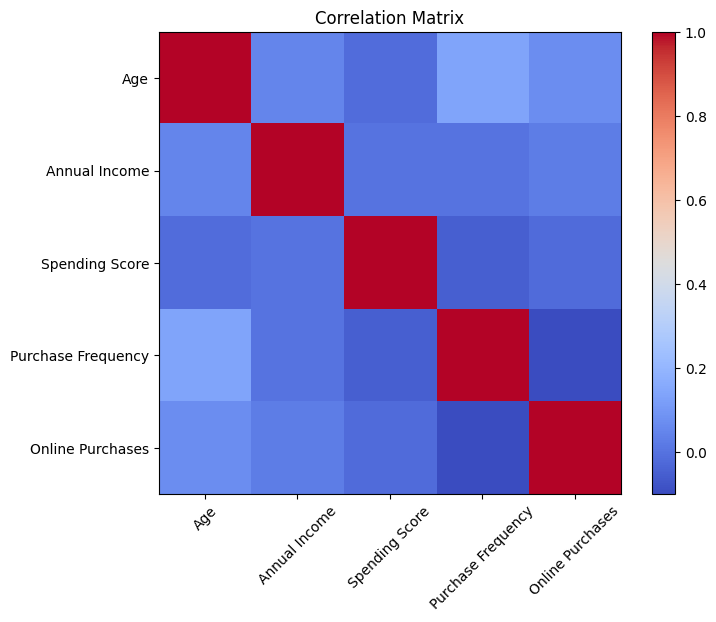

In [16]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

In [17]:
X = df[['Age', 'Annual Income', 'Spending Score']]

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [20]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

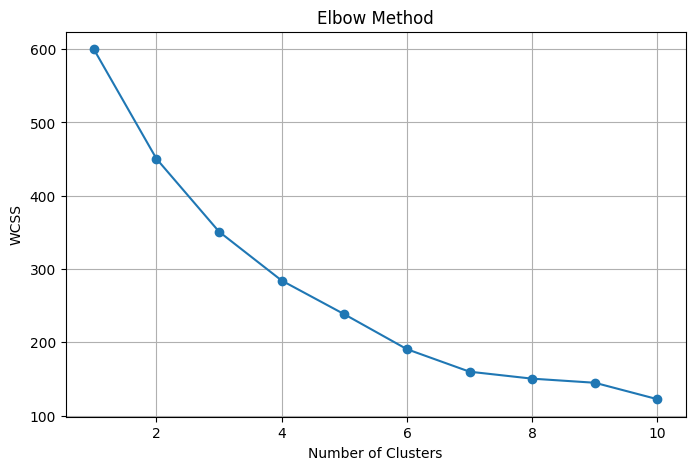

In [21]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [23]:
df.head(10)

,CustomerID,Age,Gender,City,Annual Income,Spending Score,Purchase Frequency,Online Purchases,Cluster
0,C001,58,Male,Visakhapatnam,34592,4,24,8,3
1,C002,26,Male,Bengaluru,116530,14,22,17,4
2,C003,45,Male,Bengaluru,24165,4,3,6,3
3,C004,56,Female,Visakhapatnam,23478,72,7,20,3
4,C005,46,Male,Chennai,97236,36,26,0,4
5,C006,39,Male,Hyderabad,56421,20,7,10,3
6,C007,42,Female,Hyderabad,32676,46,28,11,2
7,C008,64,Male,Bengaluru,80217,69,4,12,1
8,C009,36,Male,Hyderabad,128711,81,20,11,0
9,C010,20,Male,Visakhapatnam,106673,30,25,9,0


In [24]:
df['Cluster'].value_counts()

,count
Cluster,
2,55
0,39
4,37
3,35
1,34


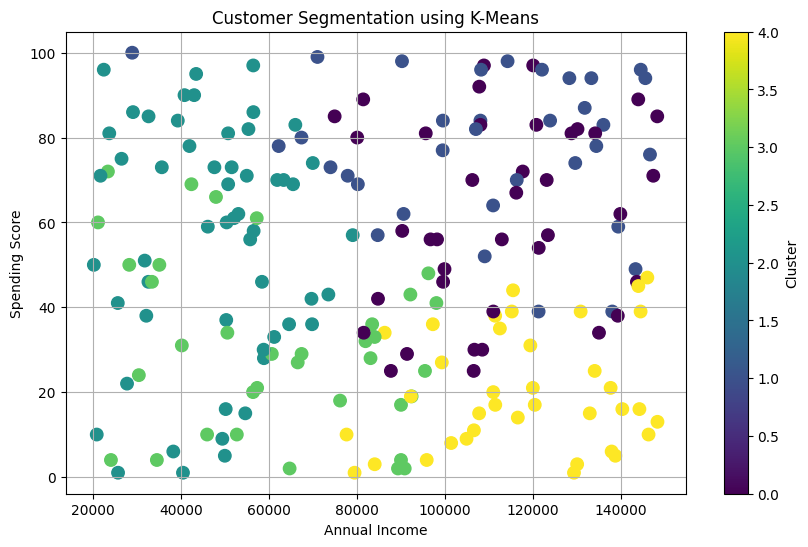

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income'],
    df['Spending Score'],
    c=df['Cluster'],
    cmap='viridis',
    s=80
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

In [26]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers = pd.DataFrame(
    centers,
    columns=['Age', 'Annual Income', 'Spending Score']
)

cluster_centers

,Age,Annual Income,Spending Score
0,25.974359,112066.974359,62.076923
1,54.058824,109330.176471,77.529412
2,31.236364,47471.381818,55.581818
3,55.257143,62417.914286,30.485714
4,40.270270,118103.054054,20.378378


In [27]:
df.to_excel("Customer_Segmentation_Output.xlsx", index=False)

In [28]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score', 'Purchase Frequency', 'Online Purchases']].mean()

cluster_summary

,Age,Annual Income,Spending Score,Purchase Frequency,Online Purchases
Cluster,,,,,
0,25.974359,112066.974359,62.076923,14.897436,10.435897
1,54.058824,109330.176471,77.529412,16.470588,10.617647
2,31.236364,47471.381818,55.581818,15.527273,9.672727
3,55.257143,62417.914286,30.485714,19.114286,12.342857
4,40.270270,118103.054054,20.378378,18.000000,10.027027


In [29]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score', 'Purchase Frequency', 'Online Purchases']].mean()
print(cluster_summary)

               Age  Annual Income  Spending Score  Purchase Frequency  \
Cluster                                                                 
0        25.974359  112066.974359       62.076923           14.897436   
1        54.058824  109330.176471       77.529412           16.470588   
2        31.236364   47471.381818       55.581818           15.527273   
3        55.257143   62417.914286       30.485714           19.114286   
4        40.270270  118103.054054       20.378378           18.000000   

         Online Purchases  
Cluster                    
0               10.435897  
1               10.617647  
2                9.672727  
3               12.342857  
4               10.027027  
